In [1]:
import slangpy as spy
from pyglm import glm
import torch
from matplotlib import pyplot as plt

from cs248a_renderer import setup_device, RendererModules
from cs248a_renderer.model.cameras import PerspectiveCamera
from cs248a_renderer.renderer.core_renderer import Renderer
from cs248a_renderer.model.volumes import DenseVolume
from cs248a_renderer.model.transforms import Transform3D

%load_ext autoreload
%autoreload 2

device = setup_device([])
renderer_modules = RendererModules(device)

[WARN] No supported shader model found, pretending to support sm_6_0.


In [2]:
OUTPUT_IMG_SIZE = (800, 800)
output_image = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.rgba32_float,
    usage=spy.TextureUsage.unordered_access,
    width=OUTPUT_IMG_SIZE[0],
    height=OUTPUT_IMG_SIZE[1],
)
# Setup the renderer
renderer = Renderer(
    device=device,
    render_texture=output_image,
    render_modules=renderer_modules
)
renderer.sqrt_spp = 1
renderer._ambientColor = glm.vec4(0.0, 0.0, 0.0, 0.0)
# Create camera
camera = PerspectiveCamera()

In [3]:
from cs231nfinal.data import DatasetID, DataSet
import numpy as np
from openvdb import FloatGrid

dataset = DataSet.Get(DatasetID.SMOKE_LOWRES)

data_array = np.zeros(dataset.resolution)
grid = dataset.get_grid("density", frame=80, type=FloatGrid)
grid.copyToArray(data_array, ijk=(0,0,0))

In [4]:
dense_volume = DenseVolume(
    name="volume",
    data=np.broadcast_to(
        data_array[:,:,:,np.newaxis], 
        (*dataset.resolution, 4)
    ).astype(np.float32),
    transform=Transform3D(),
    properties={
        "pivot": (0.5, 0.5, 0.5),
        "voxel_size": dataset.voxel_size,
    },
)

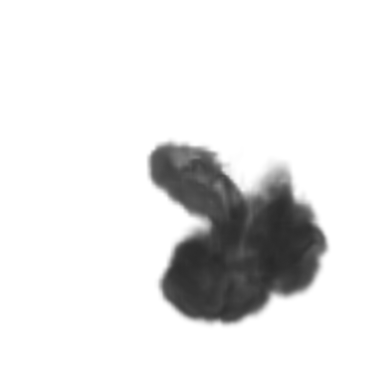

In [5]:
camera.transform.position = glm.vec3(0, 0, 30)
camera.transform.rotation = glm.quat(0, 0, 0, 1)
camera.fov = 35

renderer.load_volume(volume=dense_volume)
renderer.render(camera.view_matrix(), camera.fov)

img_res = torch.tensor(np.flipud(output_image.to_numpy()).copy(), requires_grad=True)
plt.imshow(img_res.detach().numpy())
plt.axis("off")
plt.show()